In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
import tensorflow_datasets as tfds

(train_ds, val_ds), ds_info = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:]'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)

# Resize and normalize images
def format_img(image, label):
    image = tf.image.resize(image, (180, 180))
    image = image / 255.0
    return image, label

train_ds = train_ds.map(format_img).batch(32).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.map(format_img).batch(32).prefetch(buffer_size=tf.data.AUTOTUNE)


In [3]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(180, 180, 3)),
    MaxPooling2D(),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')  # 5 flower classes
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 40s 389ms/step - accuracy: 0.3115 - loss: 3.1595 - val_accuracy: 0.5272 - val_loss: 1.2373
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 34s 365ms/step - accuracy: 0.4802 - loss: 1.2853 - val_accuracy: 0.5736 - val_loss: 1.0637
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 35s 374ms/step - accuracy: 0.5910 - loss: 1.0735 - val_accuracy: 0.5777 - val_loss: 1.0398
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 34s 363ms/step - accuracy: 0.6825 - loss: 0.8520 - val_accuracy: 0.6444 - val_loss: 0.9682
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 34s 370ms/step - accuracy: 0.7633 - loss: 0.6320 - val_accuracy: 0.5817 - val_loss: 1.1271
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 34s 370ms/step - accuracy: 0.8329 - loss: 0.4995 - val_accuracy: 0.5995 - val_loss: 1.1204
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 35s 374ms/step - accuracy: 0.8670 - loss: 0.3817 - val_accuracy: 0.5831 - val_loss: 1.4272
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 34s 365ms/step - accuracy: 0.9118 - loss: 0.3058 - val_accu

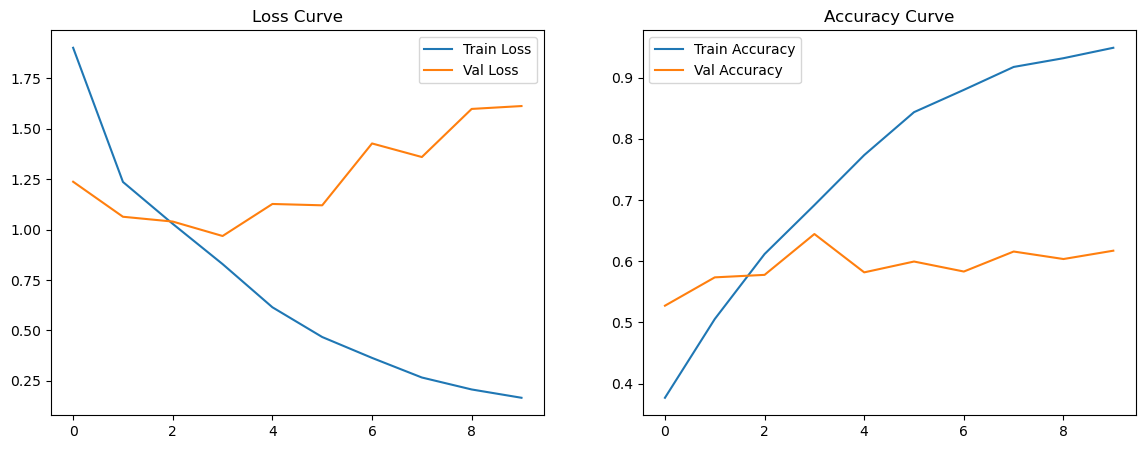

In [4]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# Plot training/validation loss and accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss Curve')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy Curve')

plt.show()


In [5]:
model.save("flower_model.h5")


In [6]:
import gradio as gr
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
from PIL import Image

model = load_model("flower_model.h5")
class_names = ds_info.features['label'].names

def predict(img):
    img = img.resize((180, 180))
    img = img_to_array(img) / 255.0
    img = np.expand_dims(img, axis=0)
    pred = model.predict(img)
    return {class_names[i]: float(pred[0][i]) for i in range(5)}

gr.Interface(fn=predict,
             inputs=gr.Image(type="pil"),
             outputs=gr.Label(num_top_classes=3),
             title="Flower Classifier").launch()


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
